In [250]:
try:
    import keras
    import tensorflow
except:
    %pip install keras_preprocessing
    %pip install keras -qqq
    %pip install tensorflow -qqq
    %pip install pyserial -qqq
    %pip install matplotlib -qqq
    import keras
    import tensorflow
    import serial

In [251]:
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import clear_output
import time
import random as rd


In [252]:
import serial
serial.Serial()

Serial<id=0x7fcf91b142b0, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)

In [253]:
%pip install pyserial -qqq


Note: you may need to restart the kernel to use updated packages.


In [254]:
from keras_preprocessing import image as img

In [255]:
from PIL import Image

In [256]:
import socket
import numpy as np
import matplotlib.pyplot as plt
import struct

In [257]:
path_port_serial = "/dev/ttyUSB1"
baudrate = 115200

## Conjunto de funções dedicadas a comunicação TCP/IP - FreeRTOS

In [258]:
def connect_to_server(server_ip, server_port,string):
    """Establishes a connection to the server and returns the socket."""
    client_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client_socket.connect((server_ip, server_port))
    print(f"Connected to server at {server_ip}:{server_port} - {string}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return client_socket
def send_message(client_socket, data):
    """Sends raw data to the server."""
    client_socket.sendall(data)

def receive_message(client_socket, data_size):
    """Receives raw data from the server."""
    data = client_socket.recv(data_size)  # Receive the data of the specified size
    #print("Received data.")
    return data

In [259]:
def plot_data(sent_data, received_data):
    """Plots the sent and received data with customizations."""
    plt.figure(figsize=(10, 5))
    
    # Set background color to black
    plt.gcf().set_facecolor('black')
    
    # Plot the sent data
    plt.subplot(2, 1, 1)
    plt.title("Sent Sine Wave Data", color='white')
    plt.stem(sent_data)  # Thicker cyan line for sent data
    plt.grid(True, color='white')  # White grid lines
    plt.tick_params(axis='both', colors='white')  # White ticks

    # Plot the received data
    plt.subplot(2, 1, 2)
    plt.title("Received Signal Data", color='white')
    plt.stem(received_data)  # Thicker red line for received data
    plt.grid(True, color='white')  # White grid lines
    plt.tick_params(axis='both', colors='white')  # White ticks

    plt.tight_layout()
    plt.show()


In [260]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [261]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Bin[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
      Ain[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
  return [Ain,Bin]

In [262]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [263]:
def send_matrix_rec(X,input,fs_pc2fpga_rate):
  file = open(f"teste{input}.txt","+w")
   
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = baudrate
  s.bytesize = 8

  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    conc = 0
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      conc += X[j][i]*pow(10,j)
      time.sleep(1/fs_pc2fpga_rate)
    if(fs_pc2fpga_rate <10):
      strr = str(conc)[::-1]
      print(f'{strr}',"\n")
  s.write(bytearray([0xad]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xda]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

In [264]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    #s.timeout = .5#(size**2+2)/baudrate
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    a = s.read()
    print(a)
    #if(a != 239 and a != 254):
    #    return Y
    while(True):
        try:
            a = s.read()[0]
        except IndexError:
            print("Matriz corrompida...")
            return Y
        if(a==b''):
            print("Vazio")
            return Y
        if(a!=0 and a!=254 and a!=239 and a!= 255):

            i+=1
            Y[index_row][index_col] = a
            index_col +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_col = 0
        if(i == size**2 or flag ):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [265]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [266]:
def transmitter_uart(M,fs_pc2fpga_rate):
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M_p)
    send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate)
    send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate)

In [267]:

delay = 1/1000
def send1(Asyst,delay = 1/1000):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xad]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    print("Connection closed.")
           
    client_socket.close()

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [268]:
#A,B = np.array(create_matrix(3,1))
#Asyst ,Bsyst = shiftMatrixSystolic(A,B)
#send1(Asyst,delay = 1)
#send(Bsyst,delay = 5)

In [269]:


def send2(Asyst,delay = 1/1000):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    data_vec_bytes = bytearray(data_vec)
    send_message(client_socket, data_vec_bytes)
    print(data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    data_vec_bytes = bytearray(data_vec)
    send_message(client_socket, data_vec_bytes)

    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
            time.sleep(delay)
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            data_vec_bytes = bytearray(data_vec)
            send_message(client_socket, data_vec_bytes)
            print("index: ",i, i+j*16,",", "Data: ",data_vec)
           # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            # Receive the response (assuming the server sends 32-bit integers)
            #raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            # Plot the sent and received data
            #plot_data(data_vec, received_data)
            # Close the connection
        print(strr)
    time.sleep(delay)
    data_vec = [0xad]
    data_vec_bytes = bytearray(data_vec)
    print(data_vec_bytes)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    data_vec_bytes = bytearray(data_vec)

    send_message(client_socket, data_vec_bytes)
    print("Connection closed.")
           
    #client_socket.close()

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [270]:
#A,B = np.array(create_matrix(16,1))
#Asyst ,Bsyst = shiftMatrixSystolic(A,B)
#send2(Asyst,delay = 1/1000)

In [271]:


def send(Asyst,delay = 1/1000,k=500):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+1}) = 0xff;")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+2}) = 0xff;")

    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #client_socket.close()
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)

    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
           
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            time.sleep(delay)
            data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
           
     #       send_message(client_socket, data_vec_bytes)
            
            print(f"*(SourceAddr + {k+3}) = {data_vec[0]};")
            
        #print("index: ",i, k,",", "Data: ",data_vec)
            k+=1
           # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            # Receive the response (assuming the server sends 32-bit integers)
            #raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            # Plot the sent and received data
            #plot_data(data_vec, received_data)
            # Close the connection
        

      #  print(strr)
        #time.sleep(2)
    #data_vec = [0xad]
    #data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #time.sleep(delay)
    #client_socket.close()
    ## Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    time.sleep(delay)
    data_vec = [0xad]
    print(f"*(SourceAddr + {k+3}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    print(f"*(SourceAddr + {k+4}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
#    send_message(client_socket, data_vec_bytes)
    #client_socket.close()


In [272]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)


Aaa=array([[4, 3, 3, 2, 2, 1, 3, 2, 1, 2, 4, 4, 2, 3, 2, 2],
       [4, 3, 1, 2, 3, 3, 1, 2, 1, 4, 2, 1, 4, 3, 4, 3],
       [4, 2, 1, 3, 1, 3, 1, 2, 4, 4, 4, 3, 1, 3, 2, 1],
       [1, 4, 3, 1, 2, 3, 1, 3, 2, 1, 4, 2, 1, 2, 4, 2],
       [4, 4, 2, 2, 3, 1, 1, 4, 3, 3, 2, 1, 2, 3, 2, 4],
       [4, 4, 2, 1, 4, 1, 1, 4, 3, 2, 4, 1, 3, 2, 1, 1],
       [2, 4, 4, 2, 2, 3, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1],
       [1, 2, 4, 2, 1, 3, 2, 1, 2, 3, 2, 1, 3, 3, 4, 2],
       [2, 3, 1, 2, 4, 2, 1, 2, 1, 1, 2, 1, 2, 3, 2, 1],
       [1, 2, 3, 3, 2, 2, 4, 3, 3, 4, 4, 4, 3, 3, 2, 2],
       [3, 4, 1, 3, 4, 4, 3, 2, 3, 3, 3, 4, 1, 2, 1, 3],
       [3, 4, 2, 3, 4, 3, 1, 1, 4, 1, 1, 1, 2, 2, 4, 1],
       [1, 4, 3, 2, 4, 2, 4, 3, 4, 3, 4, 1, 2, 4, 4, 3],
       [2, 2, 2, 2, 3, 4, 3, 1, 1, 3, 3, 3, 4, 4, 1, 1],
       [3, 1, 3, 1, 4, 2, 1, 1, 4, 1, 1, 4, 3, 3, 3, 3],
       [3, 4, 2, 3, 3, 1, 4, 4, 3, 1, 2, 4, 1, 4, 3, 3]])

 Bbb=      array([[4, 4, 3, 2, 4, 4, 1, 1, 1, 4, 1, 2, 3, 4, 4, 1],
       [2, 4, 1, 2, 2, 4, 1, 2, 4, 4, 4, 3, 4, 2, 4, 3],
       [1, 4, 4, 4, 3, 2, 4, 4, 1, 3, 1, 1, 2, 3, 2, 3],
       [4, 2, 2, 3, 4, 4, 1, 1, 1, 1, 1, 1, 2, 3, 4, 3],
       [2, 3, 4, 3, 1, 4, 2, 4, 4, 3, 3, 2, 4, 2, 2, 3],
       [1, 4, 1, 4, 3, 4, 4, 2, 4, 2, 2, 2, 3, 4, 4, 3],
       [4, 3, 4, 2, 4, 4, 3, 3, 2, 3, 2, 4, 2, 1, 3, 2],
       [1, 2, 1, 2, 3, 4, 2, 2, 3, 1, 4, 3, 3, 2, 2, 1],
       [4, 3, 4, 4, 3, 3, 4, 2, 2, 4, 2, 2, 1, 2, 1, 4],
       [3, 1, 4, 2, 4, 1, 4, 4, 4, 3, 3, 4, 3, 1, 3, 2],
       [1, 4, 3, 2, 3, 4, 1, 3, 4, 2, 2, 1, 4, 4, 2, 1],
       [2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 4, 3, 2, 4, 4, 4],
       [4, 2, 1, 3, 4, 1, 1, 1, 2, 3, 3, 1, 2, 2, 3, 2],
       [2, 4, 1, 1, 2, 4, 4, 4, 2, 4, 3, 1, 4, 1, 4, 4],
       [2, 1, 4, 4, 1, 3, 4, 1, 3, 1, 3, 3, 4, 1, 1, 3],
       [2, 4, 1, 3, 3, 1, 3, 2, 2, 1, 1, 4, 2, 3, 4, 2]])

In [273]:


def send_debug(Asyst,delay = 1/1000,k=500):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+1}) = 0xff;")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+2}) = 0xff;")

    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #client_socket.close()
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)

    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
           
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            time.sleep(delay)
            data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
           
     #       send_message(client_socket, data_vec_bytes)
            
            print(f"*(SourceAddr + {k+3}) = {data_vec[0]};")
            
        #print("index: ",i, k,",", "Data: ",data_vec)
            k+=1
           # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            # Receive the response (assuming the server sends 32-bit integers)
            #raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            # Plot the sent and received data
            #plot_data(data_vec, received_data)
            # Close the connection
        

        #print(strr)
        #time.sleep(2)
    #data_vec = [0xad]
    #data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #time.sleep(delay)
    #client_socket.close()
    ## Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    time.sleep(delay)
    data_vec = [0xad]
    print(f"*(SourceAddr + {k+3}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    print(f"*(SourceAddr + {k+4}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
#    send_message(client_socket, data_vec_bytes)
    #client_socket.close()


In [274]:
Aaa=np.array([[4, 3, 3, 2, 2, 1, 3, 2, 1, 2, 4, 4, 2, 3, 2, 2],
       [4, 3, 1, 2, 3, 3, 1, 2, 1, 4, 2, 1, 4, 3, 4, 3],
       [4, 2, 1, 3, 1, 3, 1, 2, 4, 4, 4, 3, 1, 3, 2, 1],
       [1, 4, 3, 1, 2, 3, 1, 3, 2, 1, 4, 2, 1, 2, 4, 2],
       [4, 4, 2, 2, 3, 1, 1, 4, 3, 3, 2, 1, 2, 3, 2, 4],
       [4, 4, 2, 1, 4, 1, 1, 4, 3, 2, 4, 1, 3, 2, 1, 1],
       [2, 4, 4, 2, 2, 3, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1],
       [1, 2, 4, 2, 1, 3, 2, 1, 2, 3, 2, 1, 3, 3, 4, 2],
       [2, 3, 1, 2, 4, 2, 1, 2, 1, 1, 2, 1, 2, 3, 2, 1],
       [1, 2, 3, 3, 2, 2, 4, 3, 3, 4, 4, 4, 3, 3, 2, 2],
       [3, 4, 1, 3, 4, 4, 3, 2, 3, 3, 3, 4, 1, 2, 1, 3],
       [3, 4, 2, 3, 4, 3, 1, 1, 4, 1, 1, 1, 2, 2, 4, 1],
       [1, 4, 3, 2, 4, 2, 4, 3, 4, 3, 4, 1, 2, 4, 4, 3],
       [2, 2, 2, 2, 3, 4, 3, 1, 1, 3, 3, 3, 4, 4, 1, 1],
       [3, 1, 3, 1, 4, 2, 1, 1, 4, 1, 1, 4, 3, 3, 3, 3],
       [3, 4, 2, 3, 3, 1, 4, 4, 3, 1, 2, 4, 1, 4, 3, 3]])

Bbb=      np.array([[4, 4, 3, 2, 4, 4, 1, 1, 1, 4, 1, 2, 3, 4, 4, 1],
       [2, 4, 1, 2, 2, 4, 1, 2, 4, 4, 4, 3, 4, 2, 4, 3],
       [1, 4, 4, 4, 3, 2, 4, 4, 1, 3, 1, 1, 2, 3, 2, 3],
       [4, 2, 2, 3, 4, 4, 1, 1, 1, 1, 1, 1, 2, 3, 4, 3],
       [2, 3, 4, 3, 1, 4, 2, 4, 4, 3, 3, 2, 4, 2, 2, 3],
       [1, 4, 1, 4, 3, 4, 4, 2, 4, 2, 2, 2, 3, 4, 4, 3],
       [4, 3, 4, 2, 4, 4, 3, 3, 2, 3, 2, 4, 2, 1, 3, 2],
       [1, 2, 1, 2, 3, 4, 2, 2, 3, 1, 4, 3, 3, 2, 2, 1],
       [4, 3, 4, 4, 3, 3, 4, 2, 2, 4, 2, 2, 1, 2, 1, 4],
       [3, 1, 4, 2, 4, 1, 4, 4, 4, 3, 3, 4, 3, 1, 3, 2],
       [1, 4, 3, 2, 3, 4, 1, 3, 4, 2, 2, 1, 4, 4, 2, 1],
       [2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 4, 3, 2, 4, 4, 4],
       [4, 2, 1, 3, 4, 1, 1, 1, 2, 3, 3, 1, 2, 2, 3, 2],
       [2, 4, 1, 1, 2, 4, 4, 4, 2, 4, 3, 1, 4, 1, 4, 4],
       [2, 1, 4, 4, 1, 3, 4, 1, 3, 1, 3, 3, 4, 1, 1, 3],
       [2, 4, 1, 3, 3, 1, 3, 2, 2, 1, 1, 4, 2, 3, 4, 2]])

In [275]:
Aaaasyst ,Bbbbsyst = shiftMatrixSystolic(Aaa,Bbb)
send_debug(Bbbbsyst,delay = 1/1000,k=499)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
*(SourceAddr + 500) = 0xff;
*(SourceAddr + 501) = 0xff;
*(SourceAddr + 502) = 0;
*(SourceAddr + 503) = 0;
*(SourceAddr + 504) = 0;
*(SourceAddr + 505) = 0;
*(SourceAddr + 506) = 0;
*(SourceAddr + 507) = 0;
*(SourceAddr + 508) = 0;
*(SourceAddr + 509) = 0;
*(SourceAddr + 510) = 0;
*(SourceAddr + 511) = 0;
*(SourceAddr + 512) = 0;
*(SourceAddr + 513) = 0;
*(SourceAddr + 514) = 0;
*(SourceAddr + 515) = 0;
*(SourceAddr + 516) = 0;
*(SourceAddr + 517) = 1;
*(SourceAddr + 518) = 0;
*(SourceAddr + 519) = 0;
*(SourceAddr + 520) = 0;
*(SourceAddr + 521) = 0;
*(SourceAddr + 522) = 0;
*(SourceAddr + 523) = 0;
*(SourceAddr + 524) = 0;
*(SourceAddr + 525) = 0;
*(SourceAddr + 526) = 0;
*(SourceAddr + 527) = 0;
*(SourceAddr + 528) = 0;
*(SourceAddr + 529) = 0;
*(SourceAddr + 530) = 0;
*(SourceAddr + 531) = 0;
*(SourceAddr + 532) = 4;
*(SourceAddr + 533) = 3;
*(SourceAddr + 534) = 0;
*(SourceAddr + 535) = 0;
*(SourceAddr + 536) = 0;
*(SourceAd

In [276]:
send_debug(Aaaasyst,delay = 1/1000,k=500)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
*(SourceAddr + 501) = 0xff;
*(SourceAddr + 502) = 0xff;
*(SourceAddr + 503) = 0;
*(SourceAddr + 504) = 0;
*(SourceAddr + 505) = 0;
*(SourceAddr + 506) = 0;
*(SourceAddr + 507) = 0;
*(SourceAddr + 508) = 0;
*(SourceAddr + 509) = 0;
*(SourceAddr + 510) = 0;
*(SourceAddr + 511) = 0;
*(SourceAddr + 512) = 0;
*(SourceAddr + 513) = 0;
*(SourceAddr + 514) = 0;
*(SourceAddr + 515) = 0;
*(SourceAddr + 516) = 0;
*(SourceAddr + 517) = 0;
*(SourceAddr + 518) = 3;
*(SourceAddr + 519) = 0;
*(SourceAddr + 520) = 0;
*(SourceAddr + 521) = 0;
*(SourceAddr + 522) = 0;
*(SourceAddr + 523) = 0;
*(SourceAddr + 524) = 0;
*(SourceAddr + 525) = 0;
*(SourceAddr + 526) = 0;
*(SourceAddr + 527) = 0;
*(SourceAddr + 528) = 0;
*(SourceAddr + 529) = 0;
*(SourceAddr + 530) = 0;
*(SourceAddr + 531) = 0;
*(SourceAddr + 532) = 0;
*(SourceAddr + 533) = 3;
*(SourceAddr + 534) = 4;
*(SourceAddr + 535) = 0;
*(SourceAddr + 536) = 0;
*(SourceAddr + 537) = 0;
*(SourceAd

array([[ 96, 122, 101,  99, 111, 121,  94,  93,  95, 106,  98,  91, 116,
        103, 122,  99],
       [102, 117,  98, 109, 116, 121, 103,  92, 110, 106, 102,  96, 124,
         96, 124, 100],
       [ 98, 114, 100, 101, 113, 121, 100,  88,  99, 104,  94,  87, 111,
        101, 116, 100],
       [ 72, 110,  88, 100,  91, 114,  94,  84, 100,  88,  93,  82, 110,
         90,  99,  93],
       [100, 124,  98, 106, 116, 125, 101,  96, 105, 109, 101,  98, 119,
         97, 121, 100],
       [ 91, 117,  95,  97, 107, 123,  84,  91, 103, 107,  98,  82, 114,
         94, 106,  89],
       [ 74, 101,  82,  92,  89, 102,  88,  79,  84,  89,  82,  74,  95,
         82,  98,  90],
       [ 85, 104,  93, 103, 102, 103, 104,  87,  91,  92,  85,  80, 102,
         82, 102,  96],
       [ 70,  91,  71,  78,  78, 100,  71,  72,  82,  80,  78,  64,  94,
         71,  89,  78],
       [110, 127, 116, 117, 129, 130, 117, 109, 112, 114, 113, 105, 123,
        107, 130, 116],
       [107, 134, 108, 115, 121, 137, 108, 102, 116, 115, 109, 107, 125,
        114, 137, 115],
       [ 94, 110,  97, 108,  97, 121,  95,  81,  96, 101,  90,  80, 108,
         88, 104, 103],
       [113, 143, 127, 129, 130, 151, 130, 122, 130, 126, 120, 113, 141,
        105, 131, 125],
       [ 95, 117,  93, 100, 111, 117,  99,  96, 101, 106,  98,  84, 113,
         96, 122, 102],
       [ 94, 113,  99, 108,  97, 106, 103,  86,  87, 102,  92,  84, 103,
         95, 108, 107],
       [110, 134, 110, 114, 119, 143, 112, 102, 107, 116, 115, 109, 128,
        106, 134, 119]])

In [277]:


def send(Asyst,delay = 1/1000,string="none"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    k = 0
    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            time.sleep(delay)
            data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
            send_message(client_socket, data_vec_bytes)
            k+=1
    time.sleep(delay)
    data_vec = [0xad]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    client_socket.close()


In [658]:


def send2(Asyst,delay = 1/1000,string="none"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here

    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =int(len(Asyst))        # Number of sine samples to send
    print("Aqui \n",NUM_SAMPLES)
    # Generate the sine wave (integer values)
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    # Send the sine wave data to the server (packed as binary)
    data_vec = Asyst
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    client_socket.close()


In [279]:
"""  """""" """ """ AAa"""  """ """ """ """

'    AAa  '

In [280]:
def matrix2vec(m):
    lin = m.shape[0]
    col = m.shape[1]
    vec = np.zeros(lin*col,dtype=int)
    k= 0
    for i in range(lin):
        for j in range(col):
            vec[k] = int(m[i][j])
            k+=1
    return vec

In [281]:
matrix2vec(Bsyst)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 2, 4, 4, 3, 3,
       1, 2, 1, 4, 1, 2, 3, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 4, 4, 4, 3, 2, 1, 2, 2, 1, 3, 4, 4, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 1, 3, 4, 4, 1, 3, 1, 4, 2, 3, 2,
       3, 1, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 4, 3,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 2, 1, 1, 3, 1, 4, 4, 4, 4, 2, 1, 2, 2, 4, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 3, 1, 3, 3, 4, 3, 1, 4,
       2, 2, 1, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 3, 1,
       3, 4, 2, 1, 3, 2, 1, 3, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 2, 1, 3, 3, 1, 1, 1, 1, 1, 2, 3, 3, 2, 3, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 2, 1, 1, 1, 2, 3, 2,
       4, 2, 4, 1, 2, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       1, 4, 2, 3, 3, 1, 1, 2, 2, 1, 1, 4, 4, 2, 2,

In [624]:
a = np.zeros(1024,dtype=int)
a = [i for i in range(len(a))]
len(a)

1024

In [656]:
len(a)

1000

In [284]:
a = np.zeros(1004,dtype=int)
a = [i for i in range(len(a))]
len(a)

1004

In [ ]:
while(True):
    send(a,delay = 0,string="OPA")
    #time.sleep(2)
    ti = time.time_ns()
    #Y = recever2(col =16,delay = 1/fdelay,string="A*B")
    tf = time.time_ns()
    break
print((tf-ti)*1e-9)


In [285]:


def recever2(col =16,delay = 1/1000,string="None"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = col
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)

    Y = np.zeros((lin,col))
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xea]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xea]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    k = 0
    for j in range(0,col):
        for i in range(0,lin):
            raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int8)
            time.sleep(delay)
            k+=1
            Y[j][i] = received_data[0]

        if(i == lin-1 and j == col -1): 
            break
    client_socket.close()
    return Y



vnstat -l -i enp4s0


In [286]:


def recever2(col =16,delay = 1/1000,string="None"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = col
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)

    Y = np.zeros((lin,col))
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xea]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xea]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    k = 0
    for j in range(0,col):
        for i in range(0,lin):
            raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            time.sleep(delay)
            k+=1
            Y[j][i] = received_data[0]

        if(i == lin-1 and j == col -1): 
            break
    client_socket.close()
    return Y



In [287]:
while(True):
    break
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    fdelay =10000000000000000000000000000000000000000000000
    #AsystVec = matrix2vec(Asyst)
    #BsystVec = matrix2vec(Bsyst)
    send(Asyst,delay = 1/fdelay,string="OPA")
    #time.sleep(2)
    send(Bsyst,delay = 1/fdelay,string="OPB")
    #time.sleep(2)
    ti = time.time_ns()
    Y = recever2(col =16,delay = 1/fdelay,string="A*B")
    tf = time.time_ns()
    break
#print((tf-ti)*1e-9)


In [288]:
ti = time.time_ns()

In [289]:
A@B

array([[ 86,  99,  89,  59,  94,  98,  80,  64,  76,  71,  76,  83,  96,
         70,  73,  97],
       [100, 101, 106,  74, 105, 111,  96,  77,  91,  87,  94,  99, 112,
         76,  90, 105],
       [ 78,  91,  89,  60,  89,  88,  62,  59,  83,  81,  74,  81,  90,
         79,  83,  96],
       [106, 110, 108,  74, 112, 123,  95,  77, 101,  93, 102, 101, 110,
         91,  94, 111],
       [102,  89, 113,  81,  99, 116,  87,  76,  93,  93, 100,  99,  92,
         97, 101,  96],
       [ 90,  95,  90,  65, 100, 109,  81,  72,  91,  81,  92,  86,  93,
         82,  85,  99],
       [104, 103, 116,  77, 101, 122, 100,  83,  99, 100, 103, 105, 109,
         94, 100, 111],
       [ 95,  88, 110,  75,  93, 107,  86,  73,  89,  93,  95,  98,  95,
         80,  90,  96],
       [107,  96, 100,  79, 103, 112,  93,  78,  88,  87,  95,  97, 104,
         86, 101, 102],
       [100, 101,  99,  76, 109, 106,  87,  77,  89,  92,  90,  99, 108,
         81, 100, 110],
       [110, 104, 114,  80,  9

In [1254]:


def recever2A(col =16,delay = 1/1000,string="None"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = col
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =256        # Number of sine samples to send
    # Generate the sine wave (integer values)
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    data_vec = [0xea,0xea]
    data_vec_bytes = struct.pack(f'{2}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    #data_vec = [0xea]
    #data_vec_bytes = struct.pack(f'{1}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
    received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
    client_socket.close()
    return received_data.reshape(16,16)



In [677]:
for i in range(len(a)):
    print(a[i],',',end='')

255 ,255 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,2 ,1 ,3 ,4 ,1 ,4 ,1 ,2 ,3 ,3 ,3 ,1 ,1 ,2 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,3 ,3 ,3 ,1 ,1 ,3 ,3 ,1 ,4 ,2 ,3 ,1 ,3 ,4 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,1 ,3 ,2 ,1 ,4 ,1 ,4 ,3 ,1 ,2 ,4 ,1 ,1 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,4 ,2 ,1 ,1 ,4 ,1 ,1 ,3 ,2 ,1 ,1 ,3 ,1 ,2 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,1 ,2 ,2 ,2 ,3 ,2 ,2 ,1 ,1 ,1 ,4 ,1 ,3 ,2 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,1 ,3 ,3 ,4 ,1 ,2 ,1 ,3 ,1 ,2 ,1 ,3 ,3 ,2 ,4 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,2 ,2 ,3 ,3 ,2 ,3 ,1 ,1 ,3 ,4 ,1 ,2 ,1 ,1 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,4 ,2 ,4 ,3 ,4 ,3 ,2 ,4 ,2 ,3 ,3 ,1 ,1 ,3 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,1 ,3 ,1 ,4 ,1 ,2 ,3 ,4 ,2 ,1 ,4 ,1 ,4 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,2 ,1 ,3 ,3 ,4 ,2 ,2 ,1 ,1 ,1 ,3 ,4 ,3 ,1 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,4 ,2 ,1 ,4 ,2 ,2 ,4 ,2 ,4 ,1 ,4 ,1 ,1 ,

In [706]:
aaa= np.array([255 ,255 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,2 ,1 ,3 ,4 ,1 ,4 ,1 ,2 ,3 ,3 ,3 ,1 ,1 ,2 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,3 ,3 ,3 ,1 ,1 ,3 ,3 ,1 ,4 ,2 ,3 ,1 ,3 ,4 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,1 ,3 ,2 ,1 ,4 ,1 ,4 ,3 ,1 ,2 ,4 ,1 ,1 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,4 ,2 ,1 ,1 ,4 ,1 ,1 ,3 ,2 ,1 ,1 ,3 ,1 ,2 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,1 ,2 ,2 ,2 ,3 ,2 ,2 ,1 ,1 ,1 ,4 ,1 ,3 ,2 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,1 ,3 ,3 ,4 ,1 ,2 ,1 ,3 ,1 ,2 ,1 ,3 ,3 ,2 ,4 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,2 ,2 ,3 ,3 ,2 ,3 ,1 ,1 ,3 ,4 ,1 ,2 ,1 ,1 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,4 ,2 ,4 ,3 ,4 ,3 ,2 ,4 ,2 ,3 ,3 ,1 ,1 ,3 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,1 ,3 ,1 ,4 ,1 ,2 ,3 ,4 ,2 ,1 ,4 ,1 ,4 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,2 ,1 ,3 ,3 ,4 ,2 ,2 ,1 ,1 ,1 ,3 ,4 ,3 ,1 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,4 ,2 ,1 ,4 ,2 ,2 ,4 ,2 ,4 ,1 ,4 ,1 ,1 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,1 ,1 ,4 ,2 ,2 ,1 ,4 ,3 ,2 ,4 ,3 ,4 ,3 ,1 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,4 ,3 ,2 ,1 ,3 ,2 ,3 ,2 ,1 ,3 ,2 ,1 ,1 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,1 ,4 ,2 ,3 ,2 ,1 ,3 ,1 ,3 ,3 ,1 ,4 ,1 ,1 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,3 ,2 ,2 ,2 ,1 ,1 ,1 ,2 ,4 ,2 ,2 ,1 ,4 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,2 ,3 ,2 ,1 ,1 ,4 ,4 ,4 ,3 ,4 ,1 ,4 ,2 ,1 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,173 ,218 ,255 ,255 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,1 ,4 ,2 ,2 ,4 ,3 ,1 ,2 ,3 ,2 ,3 ,4 ,2 ,4 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,1 ,1 ,3 ,3 ,2 ,3 ,1 ,2 ,4 ,1 ,2 ,3 ,4 ,3 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,3 ,3 ,2 ,3 ,2 ,2 ,1 ,2 ,1 ,4 ,4 ,2 ,4 ,3 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,4 ,4 ,4 ,4 ,1 ,2 ,2 ,4 ,3 ,3 ,3 ,4 ,1 ,2 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,2 ,3 ,3 ,1 ,1 ,4 ,3 ,3 ,1 ,3 ,3 ,2 ,3 ,3 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,1 ,2 ,1 ,3 ,1 ,1 ,4 ,1 ,3 ,3 ,1 ,3 ,4 ,4 ,1 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,4 ,2 ,3 ,1 ,2 ,2 ,3 ,2 ,3 ,1 ,3 ,4 ,2 ,1 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,3 ,2 ,1 ,2 ,3 ,1 ,3 ,4 ,3 ,1 ,4 ,1 ,1 ,4 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,1 ,1 ,2 ,1 ,4 ,1 ,1 ,1 ,2 ,4 ,4 ,4 ,1 ,2 ,2 ,3 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,2 ,1 ,1 ,4 ,4 ,1 ,1 ,2 ,1 ,4 ,1 ,2 ,1 ,1 ,4 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,4 ,1 ,1 ,1 ,4 ,2 ,2 ,4 ,1 ,2 ,2 ,3 ,2 ,1 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,4 ,2 ,3 ,2 ,1 ,2 ,3 ,2 ,1 ,1 ,1 ,1 ,4 ,1 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,4 ,3 ,3 ,2 ,2 ,2 ,2 ,3 ,1 ,1 ,2 ,1 ,1 ,2 ,4 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,3 ,4 ,3 ,1 ,3 ,4 ,4 ,3 ,2 ,1 ,1 ,1 ,4 ,2 ,1 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,1 ,1 ,4 ,3 ,1 ,2 ,4 ,2 ,3 ,4 ,1 ,1 ,2 ,4 ,2 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,3 ,1 ,3 ,1 ,3 ,1 ,4 ,2 ,3 ,4 ,2 ,4 ,1 ,2 ,1 ,4 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,173 ,218])

In [1000]:
len(aaa)

1000

In [1004]:
def matrix2vec(m,m0):
    return np.array(np.concat(([255,255],m.reshape(1,31*16)[0][0:],[173,218,255,255],m0.reshape(1,31*16)[0][0:],[173,218])),dtype=np.int16)

In [1342]:
i = 0
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    time.sleep(1e-9)
    Y = recever2A(col =16,delay =0,string="A*B")
    tf = time.time()
    print(f"{(tf-ti)},{i}\n")
    time.sleep(500e-3)
    i+=1

    
Y

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Aqui 
 1000
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
0.0053522586822509766,0

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Aqui 
 1000
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
0.00543975830078125,1

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Aqui 
 1000
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

KeyboardInterrupt: 

In [1275]:
Y = recever2A(col =16,delay =0,string="A*B")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


KeyboardInterrupt: 

In [1053]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)
vec = matrix2vec(Asyst.T,Bsyst)
vec

array([255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   4,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   2,   1,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   3,   2,   1,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   4,   2,
         2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         1,   3,   2,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   2,   2,   3,   2,   4,   3,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   1,   4,   1,   4,   3,   1,   1,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   3,   2,   3,   2,   3,   4,   3,
         0,   0,   0,   0,   0,   0,   0,   1,   1,   4,   1,   1,   2,
         1,   3,   3,   0,   0,   0,   0,   0,   0,   3,   2,   4,   1,
         4,   3,   1,   3,   4,   4,   0,   0,   0,   0,   0,   1,   1,
         4,   4,   4,   2,   2,   3,   1,   3,   1,   0,   0,   

while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    Y = recever2A(col =16,delay =0,string="A*B")
    tf = time.time()
    print((tf-ti))
    break


In [1077]:
Y[0:][0]

array([104, 126,  89, 115, 109, 107, 114, 116, 112,  90,  94, 122,  95,
       116,  95, 101], dtype=int32)

In [1078]:
(A@B)[0][0:]

array([104, 126,  89, 115, 109, 107, 114, 116, 112,  90,  94, 122,  95,
       116,  95, 101])

In [1036]:
(A@B)[0:][0]

array([ 96,  95, 113, 121,  93,  95,  87, 113, 105, 105,  82, 106, 109,
       100, 106,  87])

In [1034]:
Y = recever2A(col =16,delay =0,string="A*B")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


KeyboardInterrupt: 

In [739]:
Y

array([[ 92,  24,  70,  18,  49,  15,  66,  22,  78,  24,  60,  22,  59,
         20,  51,  16],
       [ 16, 114,  22,  88,   7,  85,   7,  64,  20,  73,   7,  77,  20,
         71,  17,  75],
       [ 90,  17,  83,  13,  66,  11,  87,  16,  91,  17,  87,  16,  78,
         14,  51,  11],
       [ 10,  93,  12,  87,   4,  74,   4,  67,  12,  86,   4,  69,  12,
         69,  10,  50],
       [ 83,  25,  79,  17,  59,  13,  88,  20,  98,  25,  79,  20,  84,
         22,  56,  19],
       [ 13,  78,  10,  76,   4,  80,   4,  67,  14,  76,   4,  69,  14,
         58,  11,  51],
       [ 79,  28,  82,  20,  56,  16,  93,  24,  95,  28,  70,  24,  78,
         24,  52,  20],
       [ 11,  90,  16,  84,   5,  81,   5,  99,  14, 101,   5, 106,  14,
         89,  12,  76],
       [ 71,  16,  59,  14,  46,  13,  91,  18, 104,  16,  97,  18,  99,
         12,  70,   8],
       [ 14,  65,  14,  72,   5,  68,   5,  81,  16, 100,   5,  88,  16,
         84,  13,  69],
       [ 62,  21,  73,  15,  5

In [292]:
#send(Bsyst,delay = 1/fdelay)

In [293]:
#recever2(col =16,delay = 1/fdelay)

In [294]:
#recever2(col =16,delay = 1/fdelay)

In [1171]:
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    Y = recever2A(col =16,delay =0,string="A*B")
    tf = time.time()
    print((tf-ti))
    break


 
Y

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Aqui 
 1000
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
0.030504465103149414


array([[ 96, 129, 106, 103, 105, 101, 107, 124,  92, 110,  90, 101,  97,
         98,  96, 113],
       [ 92, 116, 105,  99,  94, 110, 105, 114,  95, 114,  92, 111, 101,
        105, 106, 119],
       [ 85, 102,  96,  88,  90,  96,  88, 103,  91, 102,  82,  96,  90,
         94,  89, 112],
       [ 82, 110,  91,  98,  91,  99,  94, 107,  88, 112,  80,  96,  94,
         85,  93, 111],
       [ 83, 120, 108, 102, 105,  89, 102, 115,  90, 115,  87,  96,  99,
         96,  92, 112],
       [ 79, 117,  90,  93,  95, 100, 101, 117,  95, 110,  79,  96,  94,
        103,  96, 115],
       [106, 136, 115, 118, 112, 120, 116, 140, 110, 122,  97, 114, 114,
        111, 111, 135],
       [ 83, 106,  93,  87,  91,  90,  93, 104,  90, 106,  79,  93,  79,
         93,  89, 105],
       [ 84, 119,  97,  90, 102, 108, 102, 112,  91, 119,  85, 108, 100,
        112, 101, 110],
       [ 97, 123, 104, 112,  96, 114, 115, 125, 111, 129,  91, 104, 111,
        104, 105, 128],
       [ 69, 105,  86,  91,  8

In [1175]:
while(True):
    
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    fdelay =10000000000000000000000000000000000000000000000
    send(Asyst,delay = 1/fdelay,string="OPA")
    #time.sleep(2)
    send(Bsyst,delay = 1/fdelay,string="OPB")
    #time.sleep(2)
    ti = time.time_ns()
    Y = recever2A(col =16,delay = 1/fdelay,string="A*B")
    tf = time.time_ns()
    break
print((tf-ti)*1e-9)
Y

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPB
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


KeyboardInterrupt: 

In [296]:
np.array([114, 106,  99, 126, 123, 102, 135, 102, 141, 104, 128, 100, 129,
       117, 110, 104,  87,  84,  69,  95,  84,  77,  99,  82, 112,  81,
        93,  78,  91,  80,  91,  77, 115, 100,  92, 121, 118,  91, 126,
        96, 121, 113, 121,  93, 120, 111, 105, 115, 107,  93,  75, 102,
        97,  73, 107,  86, 107,  95, 113,  84, 100,  95,  95,  93,  81,
        74,  69,  92,  84,  66, 100,  64,  90,  73,  87,  63,  96,  79,
        79,  77,  93,  85,  80,  95,  92,  79, 105,  76, 101,  95, 102,
        73, 101,  88,  99,  88, 125, 114,  91, 117, 115,  94, 118,  96,
       122,  97, 129,  96, 116, 108, 106,  98,  89,  84,  76,  95,  90,
        76,  99,  74,  99,  89,  90,  72,  95,  82,  91,  82, 114, 102,
        85, 119, 110,  89, 127, 100, 123, 111, 119,  93, 117, 106, 111,
       111,  98,  97,  90, 107, 104,  84, 119,  78, 101, 101, 109,  86,
       109,  99,  99, 100,  86,  82,  67,  93,  79,  73,  94,  67,  88,
        79,  84,  74,  93,  77,  80,  80, 106,  98,  84, 110, 111,  88,
       127,  92, 121, 104, 126,  96, 121, 110, 102, 107,  90,  88,  81,
        98,  97,  76, 110,  75,  98,  86,  91,  72,  93,  94,  95,  77,
        82,  78,  67,  79,  78,  70,  91,  69,  88,  81,  85,  71,  82,
        78,  83,  74,  95,  89,  80, 104, 101,  82, 102,  81, 106,  94,
       101,  79, 103,  94,  94,  87,  95,  97,  72, 104,  98,  82, 115,
        74, 104,  78, 111,  86, 109,  99,  91,  84], dtype=int).reshape(16,16)

array([[114, 106,  99, 126, 123, 102, 135, 102, 141, 104, 128, 100, 129,
        117, 110, 104],
       [ 87,  84,  69,  95,  84,  77,  99,  82, 112,  81,  93,  78,  91,
         80,  91,  77],
       [115, 100,  92, 121, 118,  91, 126,  96, 121, 113, 121,  93, 120,
        111, 105, 115],
       [107,  93,  75, 102,  97,  73, 107,  86, 107,  95, 113,  84, 100,
         95,  95,  93],
       [ 81,  74,  69,  92,  84,  66, 100,  64,  90,  73,  87,  63,  96,
         79,  79,  77],
       [ 93,  85,  80,  95,  92,  79, 105,  76, 101,  95, 102,  73, 101,
         88,  99,  88],
       [125, 114,  91, 117, 115,  94, 118,  96, 122,  97, 129,  96, 116,
        108, 106,  98],
       [ 89,  84,  76,  95,  90,  76,  99,  74,  99,  89,  90,  72,  95,
         82,  91,  82],
       [114, 102,  85, 119, 110,  89, 127, 100, 123, 111, 119,  93, 117,
        106, 111, 111],
       [ 98,  97,  90, 107, 104,  84, 119,  78, 101, 101, 109,  86, 109,
         99,  99, 100],
       [ 86,  82,  67,  93,  7

In [297]:
a = [0xad]
struct.pack(f'{1}i', *a)

b'\xad\x00\x00\x00'

In [298]:
bytearray(a)

bytearray(b'\xad')

In [299]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)

In [300]:
#A@B

In [301]:

def torneio(taxa_de_transferencia,quantidade_de_op,dimensao_das_matrizes):
    ZEROS = np.zeros((dimensao_das_matrizes,dimensao_das_matrizes))
    fail =0
    bytes_enviados = 0
    bytes_recebidos = 0
    operandos_corrompidos= 0
    for i in range(quantidade_de_op+1):
        #time.sleep(((10*(dimensao_das_matrizes**2)))/baudrate)

        bytes_enviados += 2*((2*dimensao_das_matrizes-1)*dimensao_das_matrizes)*8
        bytes_recebidos += (dimensao_das_matrizes**2)*8
        clear_output(wait=True)
        print("-"*100," 100%")
        print("-"*int(100*(((i+1)/quantidade_de_op))),(i*100)/quantidade_de_op,"%")

        M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
        try:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(i))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")
        except ZeroDivisionError:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(1))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")

        X =M[0]@M[1]
        #print_matrix(X)
        transmitter_uart(M,taxa_de_transferencia)
        #time.sleep(1)
        #time.sleep(((1*(dimensao_das_matrizes**2)))/baudrate)
        #time.sleep(2)
        Y = receiver_uart(dimensao_das_matrizes)


        #print_matrix(Y)
        plt.subplot(1,2,1)
        plt.title("Calculo de Referência: PC")
        plt.imshow(X)
        plt.subplot(1,2,2)
        plt.title("Calculo obtido: FPGA")
        plt.imshow(Y)
        plt.show()
        cmp = compar_matrix(X,Y)
        operandos_corrompidos_cpm = compar_matrix(Y,ZEROS)
        if(cmp):
            fail+=1
            #return M
            #break

        if(not(operandos_corrompidos_cpm)):
            operandos_corrompidos +=1

        print("\n\n Falha" if cmp else "\n\n Sucesso",end='\n')

    return ((quantidade_de_op-fail)/(quantidade_de_op))*100,(operandos_corrompidos/quantidade_de_op)*100

In [302]:
#torneio(taxa_de_transferencia=baudrate,quantidade_de_op=100000,dimensao_das_matrizes=16)


In [303]:
from keras.preprocessing.image import img_to_array

# Visão de escalabilidade e requisitos

In [304]:
sizt =128
sizek = 3
sizeSystolicCore = np.zeros(sizt)
sizeImagemProcessada = np.zeros(sizt)

#for i in range(sizek,sizt):
#    #(Imagem-1)**2==Systolic
#    sizeImagemProcessada[i-sizek] =i
#    sizeSystolicCore[i-sizek] = 2**(np.log2((i-sizek+1)**2))
#
#plt.figure(figsize=(10,10))
#desl = 7
#plt.yticks([2**(i+desl) for i in range(sizt-desl)])
#plt.stem(sizeImagemProcessada,sizeSystolicCore,markerfmt="^")
#plt.xlabel("Tamanho da Imagem")
#plt.ylabel("Requisito Systolic")

# FILTROS e IMAGEM

In [305]:
K1 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
K1 = np.array([[1,1,1],[1,9,1],[1,1,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K1 = np.array([[1,1,1],[1,1,1],[1,1,1]])/2
K2 = np.array([[-1,0,-1],[-2,0,2],[-1,0,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K2=K1
M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
#K = np.array([[1,0],[0,-1]])
#K = np.array([[0,0],[0,1]])


In [306]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [307]:

imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [308]:
image = imga.resize([sizt, sizt])



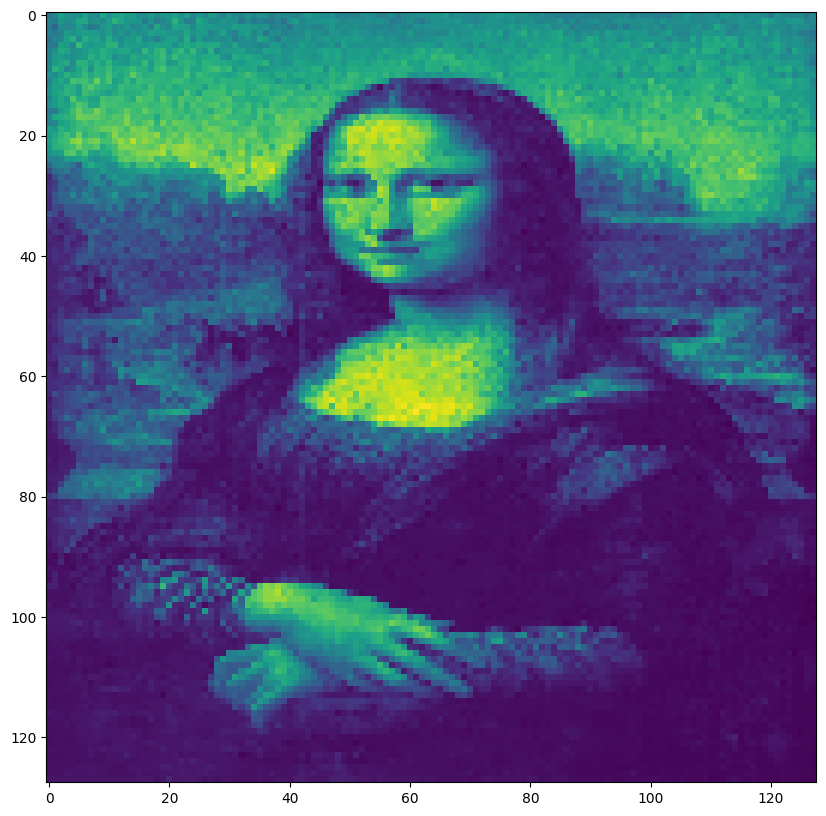

In [309]:
IMAG1 = img_to_array(image).reshape(sizt,sizt)
plt.figure(figsize=(10,10))
plt.imshow(IMAG1)
IMAG = M

In [310]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 32):
                image_norm[i][j] = 9
            else:
                image_norm[i][j] = 1
    return image_norm

In [311]:
max = IMAG1.max()

In [312]:
IMAG = np.array(((IMAG1)/max)*2**3,dtype=int)+1

In [313]:
IMAG.max()

np.int64(9)

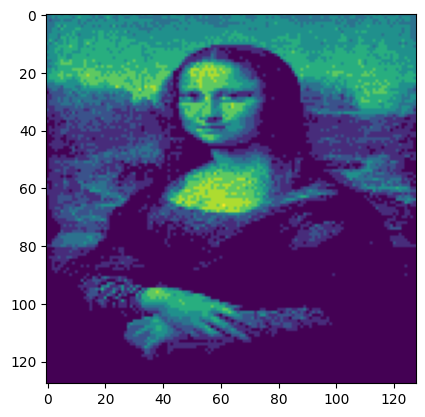

In [314]:
plt.imshow(IMAG)

In [315]:
IMAG

array([[4, 4, 5, ..., 4, 4, 4],
       [4, 4, 5, ..., 5, 4, 4],
       [4, 3, 4, ..., 5, 4, 4],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(128, 128))

In [316]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [317]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int((sizeMinicial))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[0][k]

            k+=1

    return Mout



In [318]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    sizel = M.shape[0]
    sizec = M.shape[1]
    Mout = np.zeros((sizeKernel**2,int((sizel-sizeKernel+1)**2)))
    k = 0
    for i in range(0,sizel-sizeKernel+1):
        for j in range(0,sizec-sizeKernel+1):
            '''Melhorias futuras'''
            X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            Mout[0][k+0] = X0
            Mout[1][k+0] = X1
            Mout[2][k+0] = X2
            Mout[3][k+0] = X3
            Mout[4][k+0] = X4
            Mout[5][k+0] = X5
            Mout[6][k+0] = X6
            Mout[7][k+0] = X7
            Mout[8][k+0] = X8
            #X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            #Mout[0+0][k+0] = X0
            #Mout[0+1][k+0] = X1
            #Mout[0+2][k+0] = X2
            #Mout[0+3][k+0] = X3

            #print(X0,X1,X2,X3)
            k+=1
    return Mout

In [319]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget),dtype=int)
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    if(matrix.shape[0] ==1):
       # print("Kernel_transform detec")
       #Fazendo kernel**2 copias para maior deslocamneto no janelamento
        for i in range(size_row):
            for j in  range(size_row):
                matrixMout[0][j] = matrix[0][j]
                #matrixMout[i][j] = matrix[0][j]
                #print("Aqui",matrix[i][j])
    else:
        for i in range(size_lin):
            for j in  range(size_row):
                matrixMout[i][j] = matrix[i][j]
                #print("Aqui",matrix[i][j])
    return matrixMout
    


In [320]:
a =np.array([[1,2,3,4,5,6,7,8,9]])


normalizeMatrixSIZE(matrix=a,sizeTarget=16)

array([[1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [321]:
def conv2mult(sizeTarget, inputConv,inputK,debug='off'):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    if(debug=='on'):
        print("Imagem new size:",Matrix_tranform.shape)
        print("Kernel new size:",Kernel_transform.shape)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =sizeTarget)
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=sizeTarget)
    return [matrix_target_kernel,matrix_target_image]

### Kernel no domíno base

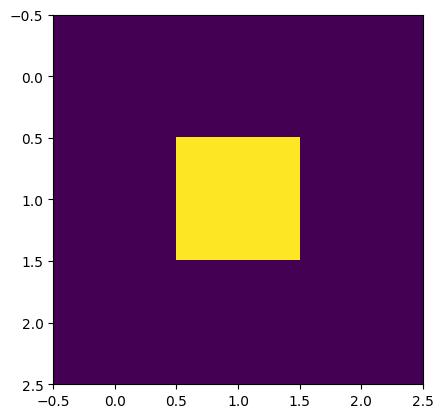

In [322]:
plt.imshow(K1)

### Imagem no domínio base

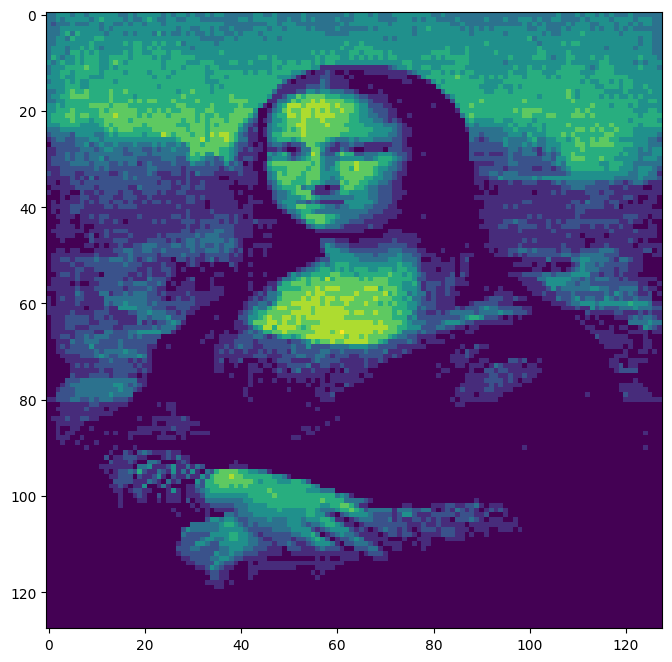

In [323]:
plt.figure(figsize=(8,8))
plt.imshow(IMAG)

In [324]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 4):
                image_norm[i][j] = 1
            else:
                image_norm[i][j] = 0
    return image_norm

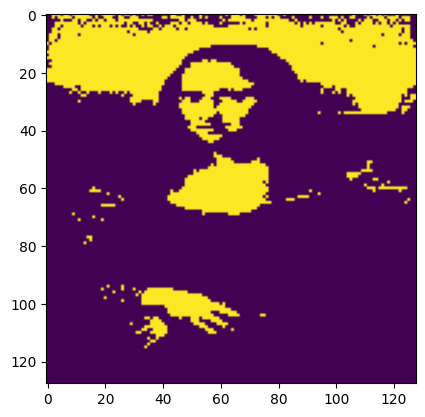

In [325]:
plt.imshow(normalizeImage(IMAG))

In [326]:
#IMAG = normalizeImage(IMAG)

In [327]:
IMAG.max()

np.int64(9)

In [328]:
#plt.figure(figsize=(500,1000))
#plt.imshow(transform_matrix(IMAG,Kern=K).T)

In [329]:
requi = 2**int(np.log2((IMAG.shape[0]-sizek)**2)+1)
print("Requisito do multiplicador:", requi)

Requisito do multiplicador: 16384


In [330]:
A1,B1 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K1)
A2,B2 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K2)

In [331]:
#A1@B1

## Kernel no novo domínio com expansão dos operandos

In [332]:
#plt.subplot(1,2,1)
#plt.imshow(A1)
#plt.subplot(1,2,2)
#plt.imshow(A2)

## Imagem no novo domínio com expansão dos operandos


In [333]:
##@plt.subplot(1,2,1)
##@plt.imshow(B1)
##@plt.subplot(1,2,2)
##@plt.imshow(B2)


In [334]:
Mout_vec1 = A1
Mout_vec2 = A2

#Resultado da Convolução no novo domínio com expansão dos operandos

In [335]:
#plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
#plt.imshow(Mout_vec1)
#plt.subplot(1,2,2)
#plt.imshow(Mout_vec2)
#plt.show()

#Resultado da Convolução no domínio base

In [336]:
Mout_vec1[:][0].shape

(16384,)

In [337]:
#cmap = "gray"
#Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
#Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
#plt.figure(figsize=(15,15))
#plt.subplot(1,2,2)
#plt.imshow(Mout1,cmap=cmap)
#plt.subplot(1,2,1)
#plt.imshow(IMAG,cmap=cmap)
#plt.show()

In [338]:
#cmap1 = "gray"
#cmap2= "binary"
#Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
#Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
#plt.figure(figsize=(15,15))
#plt.subplot(1,2,2)
#plt.imshow(Mout2,cmap=cmap2)
#plt.subplot(1,2,1)
#plt.imshow(IMAG,cmap=cmap1)
#plt.show()

In [339]:
#cmap1 = "gray"
#cmap2= "gray"
#Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
#Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
#plt.figure(figsize=(15,15))
#plt.subplot(1,2,2)
#plt.imshow(Mout2+Mout1,cmap=cmap2)
#plt.subplot(1,2,1)
#plt.imshow(IMAG,cmap=cmap1)
#plt.show()

In [340]:
def windows_slice(imagem,windows_size,imag_size,step=3):

    '''Esta função retornará uma pequena fatia da imagem base, dada uma posição relativa. Com o tamanho da unidade de mulltiplicação'''
    window_buffer = np.zeros((windows_size,windows_size))
    
    try:
        for k in range(windows_size):
             for h in range(windows_size):
                window_buffer[k][h] = imagem[windows_slice.posy_static+k][windows_slice.posx_static+h]
    except:
        print("Fora do limite da imagem, posx e posy < imag_size")
        windows_slice.posx_static = 0
        windows_slice.posy_static = 0
    windows_slice.posx_static +=step
    if(windows_slice.posx_static >= imag_size-windows_size-step-1):
        windows_slice.posx_static = 0
        windows_slice.posy_static +=step
    print(windows_slice.posx_static,windows_slice.posy_static)
    return (window_buffer,windows_slice.posy_static == imag_size-windows_size-1)


In [341]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

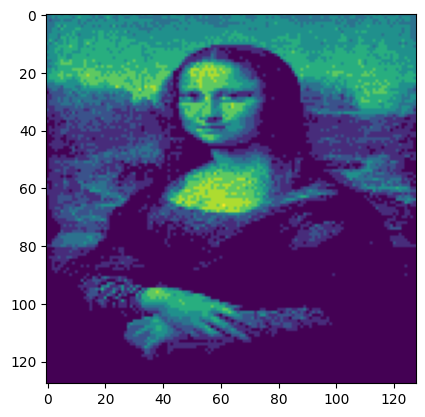

In [342]:
plt.imshow(IMAG)

In [343]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

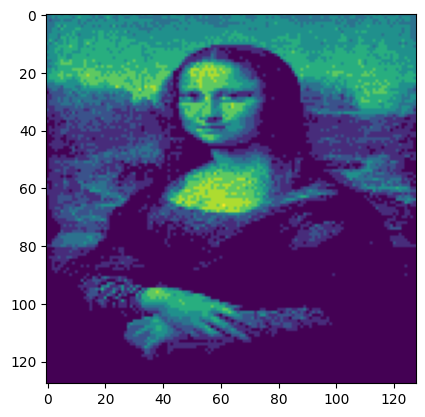

In [344]:
plt.imshow(IMAG)


In [345]:
def rebuild_image(windows_buffer_conv,size_imag,size_mult,windows_size,step=3):

    for k in range(size_mult):
     for h in range(size_mult):
        rebuild_image.window_buffer[rebuild_image.posy+k][rebuild_image.posx+h] = windows_buffer_conv[k][h]
    rebuild_image.posx +=step
    if(rebuild_image.posx >= size_imag-windows_size-step+2):
        
        if(rebuild_image.posx == size_mult and rebuild_image.posy == size_mult):
           rebuild_image.posy =size_mult
           rebuild_image.posy =size_mult
        else:   
            rebuild_image.posy +=step
            rebuild_image.posx  = 0

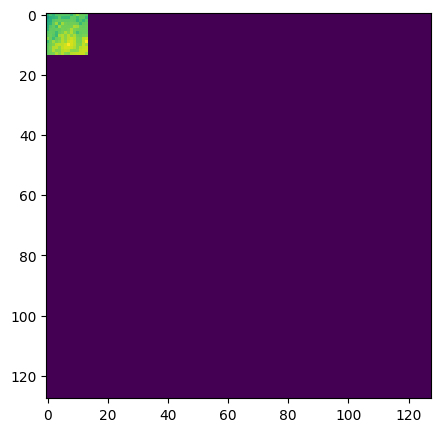

In [346]:
windows_size =16# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/30)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=256,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    break #Retire
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

In [347]:
A[1]= A[0]
A[2]= A[0]
A[3]= A[0]


In [348]:
A

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256))

# Ambiente de convolução no PC

In [349]:
K1 = np.ones((3,3))
K1[0][0] = 1
K1[1][0] = 2
K1[2][0] = 1
K1[0][2] = -1
K1[1][2] = -2
K1[2][2] = -1
K1[0][1] = 0
K1[2][1] = 0
K1[1][1] = 0
K1=K1
K1

array([[ 1.,  0., -1.],
       [ 2.,  0., -2.],
       [ 1.,  0., -1.]])

In [350]:
while(True):
    break
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        plt.subplot(1,2,1)
        plt.imshow(A)
        plt.subplot(1,2,2)

        plt.imshow(B)
        plt.show()
        print(windows_buffer_conv.shape,A.shape,B.shape)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer,cmap='gray')
        plt.subplot(1,2,2)
        plt.imshow(IMAG,cmap='gray')
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break
    

# Ambiente de convolução na FPGA


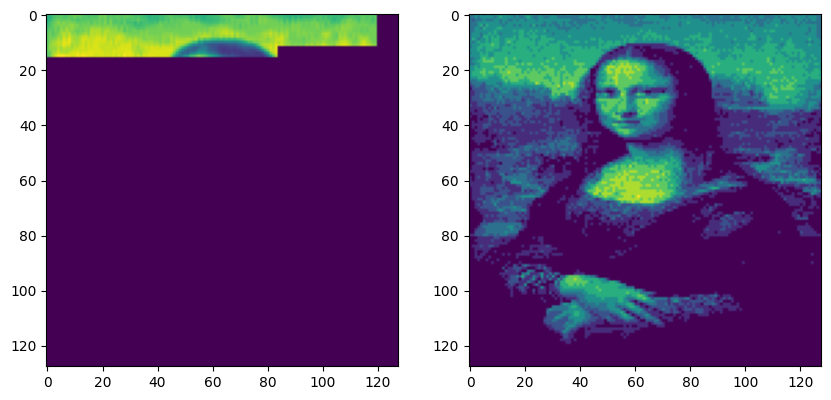

<Figure size 1000x1000 with 0 Axes>

Aqui 84 12
88 12
Imagem new size: (9, 16)
Kernel new size: (1, 9)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPB
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


KeyboardInterrupt: 

In [351]:
while(True):
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)+1#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        M_p = shiftMatrixSystolic(Asyst,Bsyst)
        send(M_p[0],delay = 1/fdelay,string="OPA")
        #time.sleep(2)
        send(M_p[1],delay = 1/fdelay,string="OPB")
        ResultMult = recever2A(col =16,delay = 1/fdelay,string="A*B")

        print(ResultMult)
        
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        plt.subplot(1,2,1)
        plt.imshow(A)
        plt.subplot(1,2,2)

        plt.imshow(B)
        plt.show()
        print(windows_buffer_conv.shape,A.shape,B.shape)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer)
        plt.subplot(1,2,2)
        plt.imshow(IMAG)
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break
    

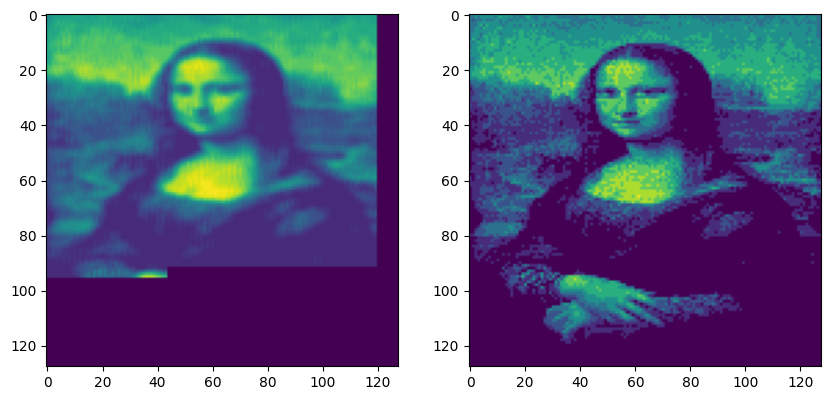

<Figure size 1000x1000 with 0 Axes>

Aqui 44 92
48 92
Imagem new size: (9, 16)
Kernel new size: (1, 9)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPB
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
4


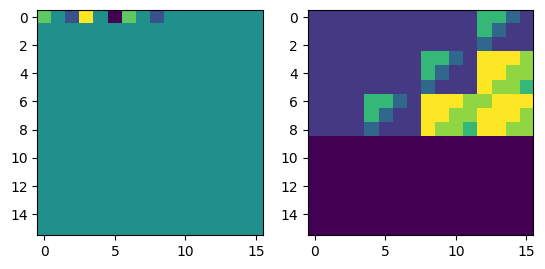

(4, 4) (16, 16) (16, 16)


In [ ]:
while(True):
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)+1#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        M_p = shiftMatrixSystolic(Asyst,Bsyst)
        send(M_p[0],delay = 1/fdelay,string="OPA")
        #time.sleep(2)
        send(M_p[1],delay = 1/fdelay,string="OPB")
        ResultMult = recever2A(col =16,delay = 1/fdelay,string="A*B")


        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        plt.subplot(1,2,1)
        plt.imshow(A)
        plt.subplot(1,2,2)

        plt.imshow(B)
        plt.show()
        print(windows_buffer_conv.shape,A.shape,B.shape)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer)
        plt.subplot(1,2,2)
        plt.imshow(IMAG)
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    
    
    

In [ ]:
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    fdelay =10000000000000000000000000000000000000000000000
    send(Asyst,delay = 1/fdelay,string="OPA")
    #time.sleep(2)
    send(Bsyst,delay = 1/fdelay,string="OPB")
    #time.sleep(2)
    ti = time.time_ns()
    Y = recever2A(col =16,delay = 1/fdelay,string="A*B")
    tf = time.time_ns()
    break
print((tf-ti)*1e-9)
Y

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
def conv2d(input_matrix, kernel):
    """
    Realiza convolução bidimensional (modo 'valid').

    input_matrix : lista de listas (H x W)
    kernel       : lista de listas (Kh x Kw)

    retorna      : matriz convoluída
    """

    H = len(input_matrix)
    W = len(input_matrix[0])

    Kh = len(kernel)
    Kw = len(kernel[0])

    # dimensões da saída (valid convolution)
    out_h = H - Kh + 1
    out_w = W - Kw + 1

    # inicializa saída
    output = [[0 for _ in range(out_w)] for _ in range(out_h)]

    # inverte o kernel (convolução verdadeira)
    kernel_flipped = [[kernel[Kh - 1 - i][Kw - 1 - j]
                       for j in range(Kw)]
                       for i in range(Kh)]

    # convolução
    for i in range(out_h):
        for j in range(out_w):
            acc = 0
            for ki in range(Kh):
                for kj in range(Kw):
                    time.sleep(1/300e+9)
                    acc += (input_matrix[i + ki][j + kj] *
                            kernel_flipped[ki][kj])
            output[i][j] = acc

    return output


In [ ]:
len(IMAG)

256

In [ ]:
t1 = time.time()
conv2d(IMAG,K1)
t2=time.time()
print(t2-t1)

1.785125732421875
